In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [50]:
import pandas as pd


# Problem Statement

###  The objective of this project is to build a machine learning model that can automatically classify online comments into predefined multiclass categories based on their textual content and associated data


### This project builds a multi-class text classifier that categorises each comment into one of four labels: 0 , 1 ,2 3

# Data Loading

In [51]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

# EDA

## Understanding the data 

In [52]:
train.head(5)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [53]:
train.shape

(198000, 15)

In [54]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [56]:
column_names = list(train.columns)


In [57]:
for i in column_names:
    print(f"{i}: {train[i].isna().sum()}")

created_date: 0
post_id: 0
emoticon_1: 0
emoticon_2: 0
emoticon_3: 0
upvote: 0
downvote: 0
if_1: 0
if_2: 0
race: 145423
religion: 145423
gender: 145423
disability: 0
comment: 1
label: 0


## --Tells us that data is heavily imbalanced--

In [58]:
train['label'].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

### for a particular post id ; upvotes 

In [59]:
train.groupby("post_id")["upvote"].apply(list)

post_id
20                                                   [1]
24     [1, 3, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, ...
31     [0, 2, 0, 1, 0, 0, 1, 3, 3, 6, 7, 0, 1, 2, 0, ...
39     [6, 5, 0, 0, 0, 0, 0, 0, 0, 1, 5, 14, 10, 2, 3...
40     [0, 2, 3, 0, 0, 0, 10, 2, 4, 1, 0, 0, 1, 1, 2,...
42                     [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0]
43                        [0, 1, 1, 1, 0, 1, 0, 1, 1, 1]
50               [0, 1, 1, 2, 0, 0, 1, 0, 1, 0, 1, 0, 0]
61     [0, 1, 0, 0, 0, 1, 0, 0, 0, 2, 0, 7, 1, 0, 0, ...
64     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
65                                                   [0]
66                                    [0, 1, 0, 0, 0, 1]
67                                          [0, 0, 0, 0]
70     [0, 1, 3, 0, 1, 2, 2, 1, 0, 2, 0, 1, 0, 2, 0, ...
71     [0, 0, 0, 1, 0, 14, 1, 1, 0, 1, 0, 19, 0, 2, 2...
72     [0, 1, 6, 0, 3, 3, 0, 0, 1, 11, 5, 3, 1, 0, 0,...
73     [0, 0, 2, 1, 1, 3, 0, 5, 4, 2, 0, 6, 2, 0, 1, ...
74                     

In [60]:
len(train["post_id"].unique())

52

In [61]:
 train["post_id"].value_counts()

post_id
72     69529
39     40946
120    24324
31     17023
73     14882
71     13308
40      5488
123     4809
118     2692
61      1149
24      1080
84       915
111      351
70       208
105      165
91       156
64       141
102      121
85       104
103       73
77        57
115       50
87        44
100       40
93        37
83        30
76        25
75        25
89        23
90        22
104       21
101       18
109       16
79        13
96        13
50        13
129       12
42        11
74        10
82        10
43        10
86         7
95         6
66         6
88         4
67         4
108        2
125        2
110        2
20         1
113        1
65         1
Name: count, dtype: int64

In [62]:
train[train["post_id"] == 71]["label"].value_counts(normalize=True)*100

label
0    62.368500
2    22.888488
1    13.397956
3     1.345056
Name: proportion, dtype: float64

## --Some Visualizations--

In [63]:
for col in train.select_dtypes(include='object').columns:
    print(col, train[col].nunique())

created_date 197996
race 6
religion 8
gender 5
comment 197842


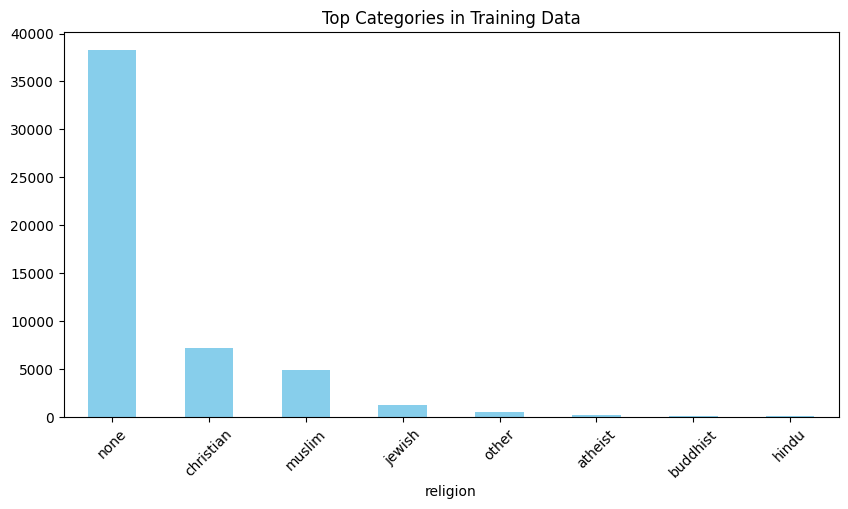

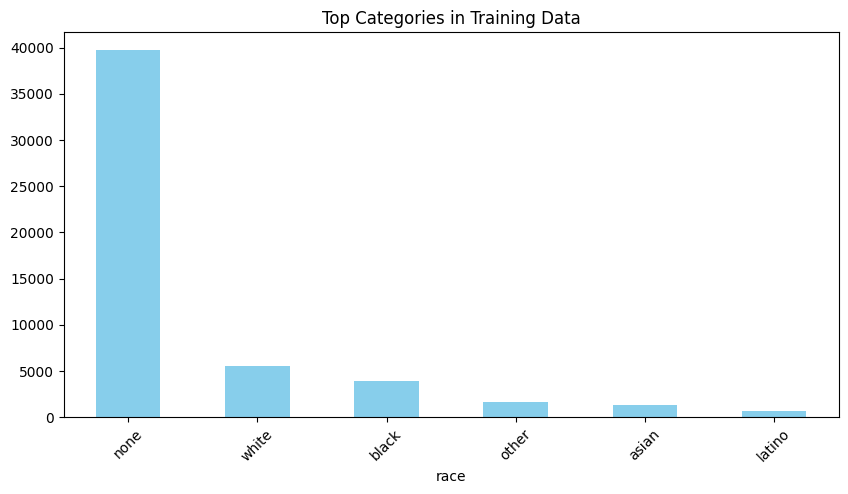

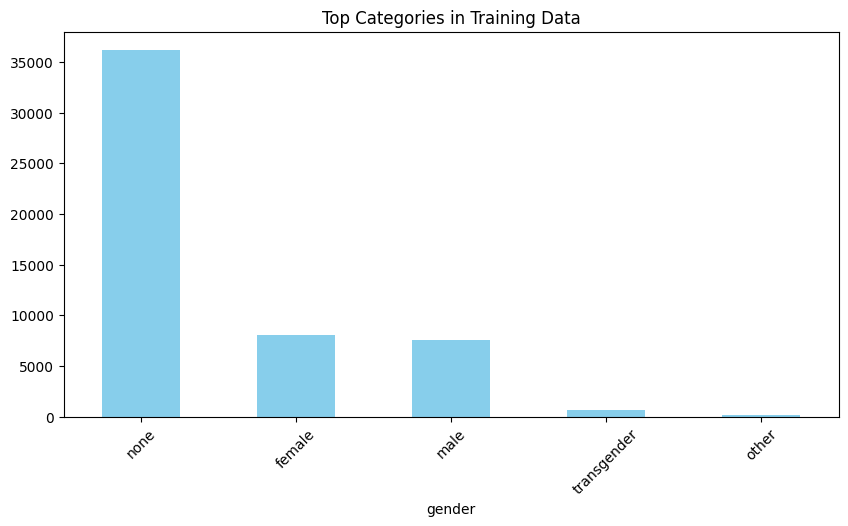

In [64]:
import matplotlib.pyplot as plt

for col in ['religion', 'race', 'gender']:
    plt.figure(figsize=(10, 5))
    train[col].value_counts().head(10).plot(kind='bar', color='skyblue')
    plt.title('Top Categories in Training Data')
    plt.xticks(rotation=45)
    plt.show()

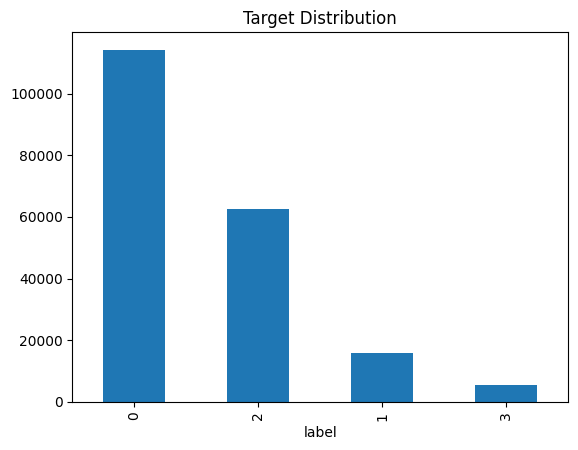

In [65]:
import matplotlib.pyplot as plt

train['label'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

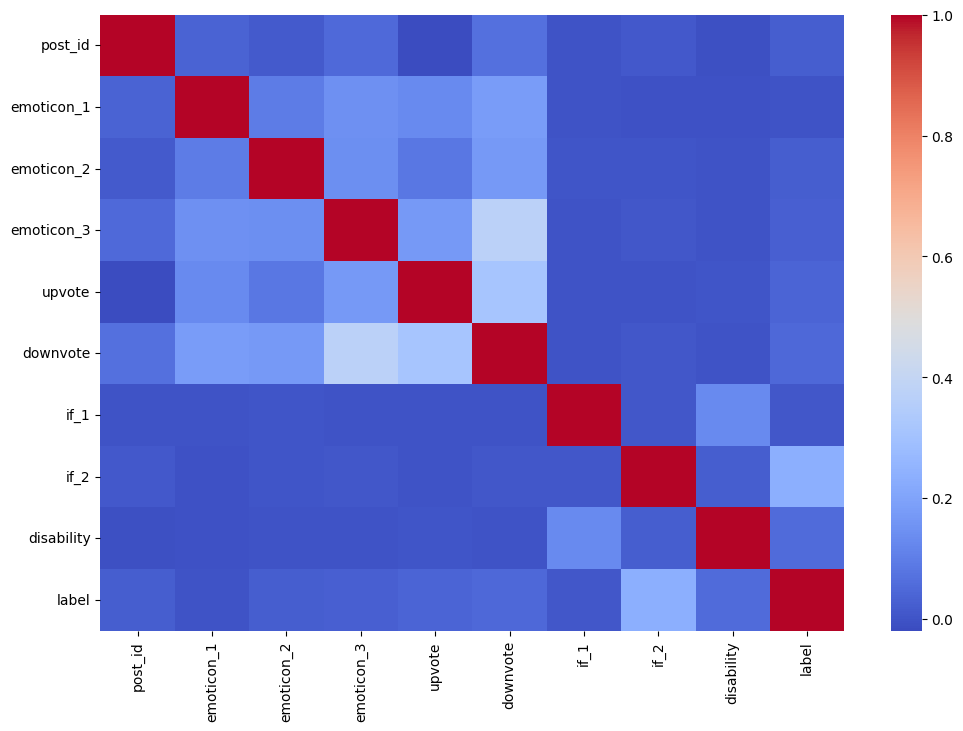

In [66]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True), cmap='coolwarm')
plt.show()

## all numerical columns are not much correlated to each other -----> the colour in them is blue 
### upvote and downvote are correlated --> could be because popular posts get both upvote and downvote 

# KEY INSIGHTS HERE 

### Label column is imbalanced 
### astronomical values of race , religion and gender are null (approx 73 %)
### upvotes and downvote are correlated , i.e. if upvote is low , downvote is low too , but they aren't correlated to 

# Feature Engineering 

In [67]:
y = train["label"]
X= train.drop("label" , axis=1)

## - Imputations -

In [68]:
from sklearn.impute import SimpleImputer
si = SimpleImputer()

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
ci = ColumnTransformer(
    [
    ("categorical" , SimpleImputer(strategy="constant",fill_value="none") ,["religion","race","gender"] )],
                       verbose_feature_names_out=True , remainder="passthrough").set_output(transform= "pandas")


In [70]:
imput_X = ci.fit_transform(X)
imput_test = ci.transform(test)

In [71]:
imput_X.head()

,categorical__religion,categorical__race,categorical__gender,remainder__created_date,remainder__post_id,remainder__emoticon_1,remainder__emoticon_2,remainder__emoticon_3,remainder__upvote,remainder__downvote,remainder__if_1,remainder__if_2,remainder__disability,remainder__comment
0,none,none,none,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,False,She might be a bright spot for a party keou on...
1,none,none,none,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,False,"Under Alaska law, a non-tribal member is not b..."
2,none,none,none,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,False,in the future please spare me your strawman dr...
3,none,none,none,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,False,"PS: That should have been ""rot"" instead of ""co..."
4,none,none,none,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,False,"Today, the confederate flag...tomorrow, the na..."


In [72]:
imput_X.columns = imput_X.columns.str.replace('categorical__', '').str.replace('remainder__', '')
display(imput_X.head())
imput_test.columns = imput_test.columns.str.replace('categorical__', '').str.replace('remainder__', '')
display(imput_test.head())

,religion,race,gender,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment
0,none,none,none,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,False,She might be a bright spot for a party keou on...
1,none,none,none,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,False,"Under Alaska law, a non-tribal member is not b..."
2,none,none,none,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,False,in the future please spare me your strawman dr...
3,none,none,none,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,False,"PS: That should have been ""rot"" instead of ""co..."
4,none,none,none,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,False,"Today, the confederate flag...tomorrow, the na..."


,religion,race,gender,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment
0,none,none,none,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,False,Canada is being run by someone with the mental...
1,none,none,none,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,False,And your comment is left-wing drivel
2,none,none,none,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,False,http://talkingpointsmemo..com/dc/special-couns...
3,none,none,none,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,False,"Trump jl Blames: The Secret Service, James Com..."
4,none,none,none,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,False,It was hard enough to get the stench out of th...


## -- New Column Creation from data--

In [73]:
# Convert 'created_date' to datetime objects
imput_X['created_date'] = pd.to_datetime(imput_X['created_date'])

# Extract temporal features
imput_X['year'] = imput_X['created_date'].dt.year
imput_X['month'] = imput_X['created_date'].dt.month
imput_X['day'] = imput_X['created_date'].dt.day
imput_X['hour'] = imput_X['created_date'].dt.hour

# Display the updated DataFrame with new features
display(imput_X.head())



,religion,race,gender,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,year,month,day,hour
0,none,none,none,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,False,She might be a bright spot for a party keou on...,2024,1,18,8
1,none,none,none,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,False,"Under Alaska law, a non-tribal member is not b...",2024,3,24,21
2,none,none,none,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,False,in the future please spare me your strawman dr...,2024,4,24,20
3,none,none,none,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,False,"PS: That should have been ""rot"" instead of ""co...",2023,5,28,22
4,none,none,none,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,False,"Today, the confederate flag...tomorrow, the na...",2023,9,9,23


In [74]:
imput_test['created_date'] = pd.to_datetime(imput_test['created_date'])

#same for test dataset 
imput_test['year'] = imput_test['created_date'].dt.year
imput_test['month'] = imput_test['created_date'].dt.month
imput_test['day'] = imput_test['created_date'].dt.day
imput_test['hour'] = imput_test['created_date'].dt.hour

display(imput_test.head())

,religion,race,gender,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,year,month,day,hour
0,none,none,none,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,False,Canada is being run by someone with the mental...,2024,2,8,13
1,none,none,none,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,False,And your comment is left-wing drivel,2024,3,1,23
2,none,none,none,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,False,http://talkingpointsmemo..com/dc/special-couns...,2024,2,9,21
3,none,none,none,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,False,"Trump jl Blames: The Secret Service, James Com...",2024,2,17,3
4,none,none,none,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,False,It was hard enough to get the stench out of th...,2024,4,24,2


## -- Encoding the categorical Data --

In [75]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output =False,handle_unknown= "ignore")
ct_ohe = ColumnTransformer([
    ("ohe" , ohe , ["race" , "religion" , "gender","disability"])
],verbose =True , verbose_feature_names_out=True,remainder = "passthrough").set_output(transform="pandas")

In [76]:
imput_X = imput_X.drop("created_date" , axis = 1)
imput_test = imput_test.drop("created_date" , axis =1)

In [77]:
ohe_X = ct_ohe.fit_transform(imput_X)

[ColumnTransformer] ........... (1 of 2) Processing ohe, total=   0.2s
[ColumnTransformer] ..... (2 of 2) Processing remainder, total=   0.0s


In [78]:
ohe_test = ct_ohe.transform(imput_test)

In [79]:
ohe_X.columns = ohe_X.columns.str.replace('ohe__', '').str.replace('remainder__', '')
display(ohe_X.head())
ohe_test.columns = ohe_test.columns.str.replace('ohe__', '').str.replace('remainder__', '')
display(ohe_test.head())

,race_asian,race_black,race_latino,race_none,race_other,race_white,religion_atheist,religion_buddhist,religion_christian,religion_hindu,...,emoticon_3,upvote,downvote,if_1,if_2,comment,year,month,day,hour
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,10,She might be a bright spot for a party keou on...,2024,1,18,8
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,6,0,0,4,"Under Alaska law, a non-tribal member is not b...",2024,3,24,21
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,10,in the future please spare me your strawman dr...,2024,4,24,20
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,5,0,0,10,"PS: That should have been ""rot"" instead of ""co...",2023,5,28,22
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,10,"Today, the confederate flag...tomorrow, the na...",2023,9,9,23


,race_asian,race_black,race_latino,race_none,race_other,race_white,religion_atheist,religion_buddhist,religion_christian,religion_hindu,...,emoticon_3,upvote,downvote,if_1,if_2,comment,year,month,day,hour
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,4,1,0,10,Canada is being run by someone with the mental...,2024,2,8,13
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,10,And your comment is left-wing drivel,2024,3,1,23
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,3,0,0,4,http://talkingpointsmemo..com/dc/special-couns...,2024,2,9,21
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,4,"Trump jl Blames: The Secret Service, James Com...",2024,2,17,3
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,11,It was hard enough to get the stench out of th...,2024,4,24,2


In [80]:
ohe_X["comment"]=ohe_X["comment"].fillna("")

In [81]:
ohe_X.columns

Index(['race_asian', 'race_black', 'race_latino', 'race_none', 'race_other',
       'race_white', 'religion_atheist', 'religion_buddhist',
       'religion_christian', 'religion_hindu', 'religion_jewish',
       'religion_muslim', 'religion_none', 'religion_other', 'gender_female',
       'gender_male', 'gender_none', 'gender_other', 'gender_transgender',
       'disability_False', 'disability_True', 'post_id', 'emoticon_1',
       'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2',
       'comment', 'year', 'month', 'day', 'hour'],
      dtype='object')

In [82]:
comment = ohe_X["comment"]
ohe_X = ohe_X.drop("comment" , axis = 1)
comment_test = ohe_test["comment"]
ohe_test = ohe_test.drop("comment" , axis = 1)

#  Preprocessing of Comment Column

## -- By removing links , chatwords , numbers , punctuations and noises --

In [83]:
comment.isna().sum()
comment_test.isna().sum()

np.int64(0)

In [84]:
comment = comment.fillna("")

In [85]:
for i in comment.head(20):
    print(i)

She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.
Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically flip the bird to the tribal court and there's nothing they can actually do. The only courts it appears he is subject to are those formally established under state and federal law, which does not recognize this.

The tribal court can at-best basically use it's influence to get tribal members and others in the community to refuse to associate with Connor and not do business with him, essentially acting like a shunning until Connor decides to leave.
in the future please spare me your strawman drivel, and if you can't manage an intelligent discussion, stick to posting on a public bathroom wall. That is not remotely what I believe. That's the mindless drivel your thoughts produced. N

In [86]:
import string
punc = string.punctuation
def remove_punct(com):
  for i in punc:
    com = com.replace(i , "")
  return com

In [87]:
def remove_links(text):
    for word in text.split():
        if word.startswith("http://") or word.startswith("https://"):
            text = text.replace(word, "")
    return text.strip()

In [88]:
num = "1234567890"
def remove_nums(com):
  for i in num:
    com = com.replace(i , "")
  return com

In [89]:
chat_words = {
    "a3": "anytime anywhere anyplace",
    "adih": "another day in hell",
    "afk": "away from keyboard",
    "afaik": "as far as i know",
    "asap": "as soon as possible",
    "asl": "age sex location",
    "atk": "at the keyboard",
    "atm": "at the moment",
    "bae": "before anyone else",
    "bak": "back at keyboard",
    "bbl": "be back later",
    "bbs": "be back soon",
    "bfn": "bye for now",
    "b4n": "bye for now",
    "brb": "be right back",
    "bruh": "bro",
    "brt": "be right there",
    "bsaaw": "big smile and a wink",
    "btw": "by the way",
    "bwl": "bursting with laughter",
    "csl": "cannot stop laughing",
    "cu": "see you",
    "cul8r": "see you later",
    "cya": "see you",
    "dm": "direct message",
    "faq": "frequently asked questions",
    "fc": "fingers crossed",
    "fimh": "forever in my heart",
    "fomo": "fear of missing out",
    "fr": "for real",
    "fwiw": "for what its worth",
    "fyp": "for you page",
    "fyi": "for your information",
    "g9": "genius",
    "gal": "get a life",
    "gg": "good game",
    "gmta": "great minds think alike",
    "gn": "good night",
    "goat": "greatest of all time",
    "gr8": "great",
    "hbd": "happy birthday",
    "ic": "i see",
    "icq": "i seek you",
    "idc": "i do not care",
    "idk": "i do not know",
    "ifyp": "i feel your pain",
    "ilu": "i love you",
    "ily": "i love you",
    "imho": "in my humble opinion",
    "imu": "i miss you",
    "imo": "in my opinion",
    "iow": "in other words",
    "irl": "in real life",
    "iykyk": "if you know you know",
    "jk": "just kidding",
    "kiss": "keep it simple stupid",
    "l": "loss",
    "l8r": "later",
    "ldr": "long distance relationship",
    "lmk": "let me know",
    "lmao": "laughing my ass off",
    "lol": "laughing out loud",
    "ltns": "long time no see",
    "m8": "mate",
    "mfw": "my face when",
    "mid": "mediocre",
    "mrw": "my reaction when",
    "mte": "my thoughts exactly",
    "nvm": "never mind",
    "nrn": "no reply necessary",
    "npc": "non player character",
    "oic": "oh i see",
    "op": "overpowered",
    "pita": "pain in the ass",
    "pov": "point of view",
    "ppl":"people",
    "prt": "party",
    "prw": "parents are watching",
    "rofl": "rolling on the floor laughing",
    "roflo l": "rolling on the floor laughing out loud",
    "rotflmao": "rolling on the floor laughing my ass off",
    "rn": "right now",
    "sk8": "skate",
    "stats": "your sex and age",
    "sus": "suspicious",
    "tbh": "to be honest",
    "tfw": "that feeling when",
    "thx": "thank you",
    "time": "tears in my eyes",
    "tldr": "too long did not read",
    "tntl": "trying not to laugh",
    "ttfn": "ta ta for now",
    "ttyl": "talk to you later",
    "u": "you",
    "u2": "you too",
    "u4e": "yours forever",
    "w": "win",
    "w8": "wait",
    "wb": "welcome back",
    "wtf": "what the fuck",
    "wtg": "way to go",
    "wuf": "where are you from",
    "wyd": "what you doing",
    "wywh": "wish you were here",
    "ya": "you",
    "zzz": "sleeping bored tired"
}

In [90]:
def expand_chat_words(text):
    words = text.split()
    expanded = []

    for w in words:
        lw = w.lower()
        if lw in chat_words:
            expanded.append(chat_words[lw])
        else:
            expanded.append(w)

    return " ".join(expanded)

In [91]:
import re
def remove_noise(text):
    text = re.sub(r'@\w+', '', text)   
    text = re.sub(r'#\w+', '', text)       
    text = re.sub(r'&\w+;', '', text)    
    return text

In [92]:
comment = comment.apply(remove_punct)
comment_test = comment_test.apply(remove_punct)
comment = comment.apply(remove_links)
comment_test = comment_test.apply(remove_links)
comment = comment.apply(remove_nums)
comment_test = comment_test.apply(remove_nums)
comment = comment.str.lower()
comment_test = comment_test.str.lower()
comment = comment.apply(expand_chat_words)
comment_test = comment_test.apply(expand_chat_words)

In [93]:
comment = comment.apply(remove_noise)
comment_test = comment_test.apply(remove_noise)

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer



## TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency) is a technique used in Natural Language Processing to convert text into numerical features that machine learning models can understand. It assigns higher importance to words that appear frequently in a document but are relatively rare across the entire dataset.

### Term Frequency (TF)

Term Frequency measures how often a word appears in a document.

TF formula:

TF(t,d) = (Number of times term *t* appears in document *d*) / (Total number of terms in document *d*)

### Inverse Document Frequency (IDF)

Inverse Document Frequency measures how rare or informative a word is across the entire corpus.

IDF formula:

IDF(t) = log ( N / df(t) )

where  
- **N** = total number of documents  
- **df(t)** = number of documents containing term *t*

### TF-IDF Score

The final TF-IDF weight is computed as:

TF-IDF(t,d) = TF(t,d) × IDF(t)

### Insight

Words that appear frequently in a document but rarely in other documents receive higher TF-IDF scores. Common words such as "the", "is", and "and" receive very low scores because they appear in most documents.

This allows the model to focus on informative words that help distinguish between different classes of comments.

---

## Word-Level vs Character-Level TF-IDF
## Word vs Char TF-IDF

| | Word TF-IDF | Char TF-IDF |
|---|---|---|
| Input | `clean_comment` (fully cleaned) | `clean_comment_light` (punctuation kept) |
| Tokenizes on | Whitespace → words/bigrams | Character n-grams (3-5) within word boundaries |
| Captures | Semantic content — *what* is said | Writing style — *how* it is said |
| Example | "stupid racist" → ["stupid", "racist", "stupid racist"] | "stupid" → ["stu","tup","upi","stup","tupi"...] |
| Bonus | Negation bigrams like "not good" | Misspellings, punctuation patterns like "!!!" |

## Why Both Together?
Word TF-IDF + Char TF-IDF = 50K + 50K = **100K features** covering both meaning and style.

---

## Combining Word and Character Features

Both word-level and character-level TF-IDF capture different types of information:

Word TF-IDF → semantic meaning of words and phrases  
Character TF-IDF → spelling patterns and subword structure

To leverage both representations, the two sparse matrices are combined using **hstack** from SciPy.


In [95]:
"""from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Word-level
tfidf_word = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_features=20000,
    strip_accents='unicode',
    analyzer='word',
     min_df=3,
    max_df=0.9
)

# Char-level
tfidf_char = TfidfVectorizer(
    ngram_range=(3, 5),
    sublinear_tf=True,
    max_features=20000,
    strip_accents='unicode',
    analyzer='char_wb',
     min_df=3,
    max_df=0.9
)

# Fit
X_word = tfidf_word.fit_transform(comment)
X_char = tfidf_char.fit_transform(comment)

# Combine
"""

'from sklearn.feature_extraction.text import TfidfVectorizer\nfrom scipy.sparse import hstack\n\n# Word-level\ntfidf_word = TfidfVectorizer(\n    stop_words="english",\n    ngram_range=(1, 2),\n    sublinear_tf=True,\n    max_features=20000,\n    strip_accents=\'unicode\',\n    analyzer=\'word\',\n     min_df=3,\n    max_df=0.9\n)\n\n# Char-level\ntfidf_char = TfidfVectorizer(\n    ngram_range=(3, 5),\n    sublinear_tf=True,\n    max_features=20000,\n    strip_accents=\'unicode\',\n    analyzer=\'char_wb\',\n     min_df=3,\n    max_df=0.9\n)\n\n# Fit\nX_word = tfidf_word.fit_transform(comment)\nX_char = tfidf_char.fit_transform(comment)\n\n# Combine\n'

In [96]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Word-level
tfidf_word = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 4),        # was (1,2) → adding trigrams captures phrases like "not good at all"
    sublinear_tf=True,
    max_features=50000,        # was 10000 → biggest single improvement
    strip_accents='unicode',
    analyzer='word',
    min_df=2,                  # was 3 → capture slightly rarer but meaningful words
    max_df=0.85                # was 0.9 → ignore very common words more aggressively
)

# Char-level
tfidf_char = TfidfVectorizer(
    ngram_range=(2, 5),        # was (3,5) → adding bigrams captures more subword patterns
    sublinear_tf=True,
    max_features=50000,        # was 10000
    strip_accents='unicode',
    analyzer='char_wb',
    min_df=2,
    max_df=0.85
)

X_word = tfidf_word.fit_transform(comment)
X_char = tfidf_char.fit_transform(comment)

In [97]:

X_word_test = tfidf_word.transform(comment_test)
X_char_test = tfidf_char.transform(comment_test)
X_tfed = hstack([X_word, X_char])
X_testef = hstack([X_word_test, X_char_test])

## Preprocessing Findings

### Steps Applied:
1. **Filled 1 row** where comment was missing with ''
2. **Filled race/religion/gender NaN** with 'none'
3. **Disability bool → int** — models need numbers not True/False
4. **Extracted date features** — hour, day, month, year from created_date
5. **Cleaned comment text** in this order:
   -Removed Punctuations → URLs → Numbers → Lowercase to remove chatwords → noises → Tf idf

### Key Insight:
- Cleaning order matters! Always lowercase first, 
  expand chat words after removing punctuation,
  remove noises at last.
- After cleaning, only meaningful words remain — 
  this will help TF-IDF focus on what actually matters.

## -- Merging comment and other columns together --

In [98]:
num_cols = ['race_asian', 'race_black', 'race_latino', 'race_none', 'race_other',
       'race_white', 'religion_atheist', 'religion_buddhist',
       'religion_christian', 'religion_hindu', 'religion_jewish',
       'religion_muslim', 'religion_none', 'religion_other', 'gender_female',
       'gender_male', 'gender_none', 'gender_other', 'gender_transgender',
       'disability_False', 'disability_True', 'post_id', 'emoticon_1',
       'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2',
     'year', 'month', 'day', 'hour']
X_n = ohe_X[num_cols].astype(float)
X_n_test = ohe_test[num_cols].astype(float)

In [99]:

from scipy.sparse import hstack
X_final_train = hstack([X_tfed ,X_n])
X_final_test = hstack([X_testef,X_n_test])

# Train Test Split and trying out different models 

In [100]:
from sklearn.model_selection import train_test_split
X_train ,X_test, y_train ,y_test = train_test_split(X_final_train , train["label"] , test_size = 0.3 , random_state = 98)

# Training models

In [101]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from lightgbm import LGBMClassifier, log_evaluation, record_evaluation
import matplotlib.pyplot as plt
import time

In [102]:
results = {}

In [103]:
scaler = MaxAbsScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)
X_tr_nn = X_tr_scaled - X_tr_scaled.min()
X_te_nn = X_te_scaled - X_te_scaled.min()
nb = MultinomialNB(alpha=0.1)
nb.fit(X_tr_nn, y_train)
score = accuracy_score(y_test, nb.predict(X_te_nn))
results["MultinomialNB"] = score


In [104]:
from sklearn.linear_model import SGDClassifier

In [105]:
modelSgd = SGDClassifier(
        loss="hinge",
        penalty="l2",
        class_weight="balanced",
        random_state=42,
        alpha=1e-05,
        max_iter=1000,
        tol=0.001,
        learning_rate='adaptive',
        eta0=0.001
    )

modelSgd.fit(X_train, y_train)

SGDClassifier(alpha=1e-05, class_weight='balanced', eta0=0.001,
              learning_rate='adaptive', random_state=42)

### - similar to linear SVC 

In [106]:
preds = modelSgd.predict(X_test)
score = accuracy_score(y_test, preds)
score

0.6906228956228956

In [110]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, n_jobs=-1)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 177.106145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6211173
[LightGBM] [Info] Number of data points in the train set: 138600, number of used features: 70403
[LightGBM] [Info] Start training from score -0.550341
[LightGBM] [Info] Start training from score -2.522757
[LightGBM] [Info] Start training from score -1.154679
[LightGBM] [Info] Start training from score -3.580925


LGBMClassifier(n_jobs=-1)

In [111]:
from lightgbm import LGBMClassifier

In [112]:
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 168.776103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6211173
[LightGBM] [Info] Number of data points in the train set: 138600, number of used features: 70403
[LightGBM] [Info] Start training from score -0.550341
[LightGBM] [Info] Start training from score -2.522757
[LightGBM] [Info] Start training from score -1.154679
[LightGBM] [Info] Start training from score -3.580925


KeyboardInterrupt: 

In [113]:
lgbm.score(X_test ,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9137542087542088

## --Hyperparameter Tuning--

In [114]:
param_grid = {
    "alpha": [1e-5, 1e-4],
    "max_iter": [100,1000],
    "tol": [1e-3, 1e-4],
    "learning_rate": ["optimal", "adaptive"],
    "eta0": [0.001, 0.01]
}

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    class_weight="balanced",
    random_state=42
)

grid = GridSearchCV(
    model,
    param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

In [ ]:
preds = model.predict(X_test)
score = accuracy_score(y_test, preds)
score

# Comparing the models and learning their macro F1 score 

In [ ]:
from sklearn.metrics import f1_score

# predictions from models
pred_model1 = lgbm.predict(X_test)
pred_model2 = best_model.predict(X_test)
pred_model3 = nb.predict(X_test)

# compute macro F1 scores
f1_model1 = f1_score(y_test, pred_model1, average="macro")
f1_model2 = f1_score(y_test, pred_model2, average="macro")
f1_model3 = f1_score(y_test, pred_model3, average="macro")

print("Macro F1 Scores")
print("----------------")
print(f"LGBMClassifier: {f1_model1:.4f}")
print(f"SGDClassifier: {f1_model2:.4f}")
print(f"MultiNomialNB: {f1_model3:.4f}")

In [ ]:
preds = lgbm.predict(X_final_test)

In [ ]:
# 5. Predict and Submit
preds = lgbm.predict(X_final_test)

submission = pd.DataFrame({'ID': sample['ID'], 'label': preds})
submission.to_csv("submission.csv", index=False)